<a href="https://colab.research.google.com/github/zmzain/zmzain/blob/main/BiLSTM_2_Layers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.7 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import optuna
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, LSTM, Bidirectional, Dense, Dropout, GlobalMaxPooling1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
# -----------------------------
# 1. Load and prepare data (Same as before)
# -----------------------------
df = pd.read_csv("https://raw.githubusercontent.com/zmzain/zmzain/89462097da8cf598cf5e1ddfc2853c4a088f3d49/data1.csv")
texts = df["Text"].astype(str).values
labels = df["class"].values

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

max_words = 20000
max_len = 100

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
X_seq = tokenizer.texts_to_sequences(texts)
X_pad = pad_sequences(X_seq, maxlen=max_len, padding="post", truncating="post")
vocab_size = min(max_words, len(tokenizer.word_index) + 1)

X_train_pad, X_test_pad, y_train, y_test = train_test_split(
    X_pad, y, test_size=0.2, random_state=42, stratify=y
)

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_pad, y_train, test_size=0.2, random_state=42, stratify=y_train
)

classes = np.unique(y_tr)
class_weights_array = compute_class_weight("balanced", classes=classes, y=y_tr)
class_weights = {int(c): float(w) for c, w in zip(classes, class_weights_array)}



In [4]:
# -----------------------------
# 2. Stacked BiLSTM Model Builder
# -----------------------------
def build_stacked_bilstm(trial, vocab_size, max_len, num_classes):
    # Hyperparameters
    embedding_dim = trial.suggest_categorical("embedding_dim", [100, 200, 300])
    units_l1      = trial.suggest_int("units_l1", 64, 256, step=64)
    units_l2      = trial.suggest_int("units_l2", 32, 128, step=32)
    dropout_rate  = trial.suggest_float("dropout_rate", 0.3, 0.5)
    lr            = trial.suggest_float("lr", 1e-4, 2e-3, log=True)

    model = Sequential()

    # Embedding with Masking
    model.add(Embedding(input_dim=vocab_size,
                        output_dim=embedding_dim,
                        input_length=max_len,
                        mask_zero=True))

    # LAYER 1: BiLSTM (Must return sequences to feed into the next LSTM)
    model.add(Bidirectional(LSTM(units_l1, return_sequences=True, dropout=dropout_rate)))

    # LAYER 2: BiLSTM (Also returns sequences so we can use GlobalMaxPooling1D)
    model.add(Bidirectional(LSTM(units_l2, return_sequences=True, dropout=dropout_rate)))

    # Pooling & Output Head
    model.add(GlobalMaxPooling1D())
    model.add(BatchNormalization()) # Added to stabilize deep BiLSTM training
    model.add(Dense(64, activation="relu"))
    model.add(Dropout(dropout_rate))
    model.add(Dense(num_classes, activation="softmax"))

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=lr),
        metrics=["accuracy"]
    )
    return model



In [5]:
# -----------------------------
# 3. Optuna objective
# -----------------------------
def objective(trial):
    tf.keras.backend.clear_session()
    model = build_stacked_bilstm(trial, vocab_size, max_len, num_classes)

    early_stop = EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
    batch_size = trial.suggest_categorical("batch_size", [16, 32, 64])

    model.fit(
        X_tr, y_tr,
        validation_data=(X_val, y_val),
        epochs=20,
        batch_size=batch_size,
        callbacks=[early_stop],
        class_weight=class_weights,
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_val, verbose=0), axis=1)
    return f1_score(y_val, y_val_pred, average="macro")


In [6]:
# -----------------------------
# 4. Run Optuna study
# -----------------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)

print(f"Best Params: {study.best_params}")


[I 2026-05-24 02:02:34,367] A new study created in memory with name: no-name-98be464f-08fb-4754-94b3-68ad8bc083c6
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
[I 2026-05-24 02:04:02,510] Trial 0 finished with value: 0.7180403602861913 and parameters: {'embedding_dim': 100, 'units_l1': 256, 'units_l2': 64, 'dropout_rate': 0.36460676327837, 'lr': 0.0008654412744687811, 'batch_size': 16}. Best is trial 0 with value: 0.7180403602861913.
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument

Best Params: {'embedding_dim': 100, 'units_l1': 256, 'units_l2': 64, 'dropout_rate': 0.4573356573541852, 'lr': 0.0005559008759845332, 'batch_size': 16}


In [7]:
# -----------------------------
# 5. Train Final Model
# -----------------------------
tf.keras.backend.clear_session()
best_model = build_stacked_bilstm(
    optuna.trial.FixedTrial(study.best_params),
    vocab_size, max_len, num_classes
)

best_model.fit(
    X_train_pad, y_train,
    validation_split=0.1,
    epochs=30,
    batch_size=study.best_params["batch_size"],
    callbacks=[EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)],
    class_weight=class_weights,
    verbose=1
)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'global_max_pooling1d' (of type GlobalMaxPooling1D) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


1037/1037 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.6241 - loss: 0.8351 - val_accuracy: 0.7473 - val_loss: 0.6084
Epoch 2/30
1037/1037 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8051 - loss: 0.4985 - val_accuracy: 0.7397 - val_loss: 0.6535
Epoch 3/30
1037/1037 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.8783 - loss: 0.3211 - val_accuracy: 0.7191 - val_loss: 0.7514
Epoch 4/30
1037/1037 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9219 - loss: 0.2165 - val_accuracy: 0.7267 - val_loss: 0.8841
Epoch 5/30
1037/1037 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9433 - loss: 0.1602 - val_accuracy: 0.7408 - val_loss: 1.0535
Epoch 6/30
1037/1037 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.9604 - loss: 0.1233 - val_accuracy: 0.7321 - val_loss: 1.3707


144/144 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

--- STACKED BiLSTM TEST REPORT ---
              precision    recall  f1-score   support

    negative       0.73      0.79      0.76      1836
     neutral       0.83      0.72      0.77      2039
    positive       0.57      0.67      0.61       733

    accuracy                           0.74      4608
   macro avg       0.71      0.72      0.71      4608
weighted avg       0.75      0.74      0.74      4608

Macro Precision: 0.7077
Macro Recall:    0.7238
Macro F1-score:  0.7126


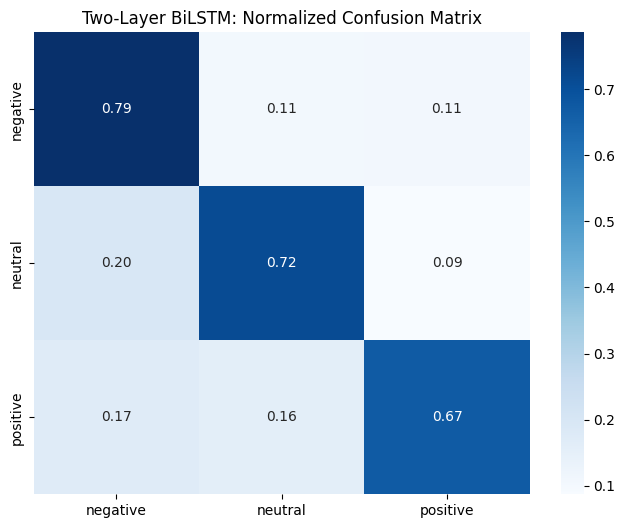

In [8]:
# -----------------------------
# 6. Final Evaluation
# -----------------------------
y_test_pred = np.argmax(best_model.predict(X_test_pad), axis=1)
print("\n--- STACKED BiLSTM TEST REPORT ---")
print(classification_report(y_test, y_test_pred, target_names=label_encoder.classes_))
p, r, f1, _ = precision_recall_fscore_support(y_test, y_test_pred, average="macro", zero_division=0)
print(f"Macro Precision: {p:.4f}")
print(f"Macro Recall:    {r:.4f}")
print(f"Macro F1-score:  {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title("Two-Layer BiLSTM: Normalized Confusion Matrix")
plt.show()